In [1]:
"""
Currency Detection Research: OCR Feature Contribution & Zero-Shot Classification
RQ3: What is the contribution of OCR-based text features?

This notebook implements:
1. Vision-only model (baseline)
2. Multi-modal model (vision + OCR features)
3. Zero-shot OCR-based denomination/country detection
"""

# ============================================================================
# INSTALLATION & IMPORTS
# ============================================================================

# Run this cell first to install dependencies
# !pip install torch torchvision pytesseract pillow pandas matplotlib scikit-learn tqdm

import os
import re
import json
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

pytesseract.pytesseract.tesseract_cmd = r'C:\Users\amith\AppData\Local\Programs\Tesseract-OCR\tesseract.exe'



# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")




Using device: cpu


In [4]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    # Data paths
    DATA_ROOT = "./Data"  # Change this to your data root
    COUNTRIES = ["thaibaht", "usdollar"]  # Add more countries as needed
    
    # Model parameters
    IMG_SIZE = 224
    BATCH_SIZE = 16
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 5
    
    # OCR parameters
    TESSERACT_CONFIG = '--oem 3 --psm 6 -l eng+tha'
    
    # Reproducibility
    SEED = 42
    
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)

In [3]:

# ============================================================================
# DATA LOADING & OCR EXTRACTION
# ============================================================================

def extract_ocr_text(image_path):
    """Extract text from banknote image using Tesseract OCR"""
    try:
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img, config=Config.TESSERACT_CONFIG)
        return text.strip()
    except Exception as e:
        print(f"Error extracting OCR from {image_path}: {e}")
        return ""

def extract_numbers_from_text(text):
    """Extract all numbers from OCR text"""
    numbers = re.findall(r'\d+', text)
    return [int(n) for n in numbers if n]

def parse_denomination_from_folder(folder_name):
    """Extract denomination value from folder name (e.g., 'THAI20' -> 20)"""
    numbers = re.findall(r'\d+', folder_name)
    return int(numbers[0]) if numbers else None

def load_dataset_with_ocr(data_root):
    """Load all images and extract OCR text"""
    data = []
    
    for country_folder in Path(data_root).iterdir():
        if not country_folder.is_dir():
            continue
            
        country = country_folder.name
        
        for denom_folder in country_folder.iterdir():
            if not denom_folder.is_dir():
                continue
            
            denomination = parse_denomination_from_folder(denom_folder.name)
            if denomination is None:
                print(f"Warning: Could not parse denomination from {denom_folder.name}")
                continue
            
            for img_file in denom_folder.glob('*'):
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    ocr_text = extract_ocr_text(img_file)
                    
                    data.append({
                        'image_path': str(img_file),
                        'country': country,
                        'denomination': denomination,
                        'ocr_text': ocr_text,
                        'ocr_numbers': extract_numbers_from_text(ocr_text)
                    })
    
    return pd.DataFrame(data)

print("Loading dataset and extracting OCR text...")
df = load_dataset_with_ocr(Config.DATA_ROOT)
print(f"Loaded {len(df)} images")
print(f"Denominations: {sorted(df['denomination'].unique())}")
print(f"\nSample OCR text:")
print(df[['denomination', 'ocr_text']].head())

Loading dataset and extracting OCR text...
Loaded 4706 images
Denominations: [np.int64(1), np.int64(2), np.int64(5), np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(500), np.int64(1000)]

Sample OCR text:
   denomination                                           ocr_text
0           100  ee Sasa\naes ie 3 se ae a\nJ Te :\n. “ae if he...
1           100  o an wry x as Sh ae = - xt\nIT yy SS oo 235 Se...
2           100  mee FR) Ne\nee My esee eatin} yey A (IN\nZp) 4...
3           100                                                   
4           100                                    Feo AE fl ND Ca


In [5]:

# ============================================================================
# OCR FEATURE ENGINEERING
# ============================================================================

class OCRFeatureExtractor:
    """Extract numerical features from OCR text"""
    
    def __init__(self, all_denominations):
        self.all_denominations = sorted(all_denominations)
        self.denom_to_idx = {d: i for i, d in enumerate(self.all_denominations)}
        self.feature_dim = len(self.all_denominations) + 10  # one-hot + additional features
        
    def extract_features(self, ocr_text, ocr_numbers):
        """Convert OCR text to fixed-size feature vector"""
        features = np.zeros(self.feature_dim, dtype=np.float32)
        
        # Feature 1: One-hot encoding for detected denominations
        for num in ocr_numbers:
            if num in self.denom_to_idx:
                features[self.denom_to_idx[num]] = 1.0
        
        # Feature 2: Max number detected (normalized)
        if ocr_numbers:
            features[len(self.all_denominations)] = max(ocr_numbers) / 1000.0
        
        # Feature 3: Min number detected (normalized)
        if ocr_numbers:
            features[len(self.all_denominations) + 1] = min(ocr_numbers) / 1000.0
        
        # Feature 4: Count of numbers detected
        features[len(self.all_denominations) + 2] = min(len(ocr_numbers) / 10.0, 1.0)
        
        # Feature 5: Text length (normalized)
        features[len(self.all_denominations) + 3] = min(len(ocr_text) / 100.0, 1.0)
        
        # Feature 6-10: Reserved for expansion
        
        return features

# Create feature extractor
ocr_extractor = OCRFeatureExtractor(df['denomination'].unique())
print(f"OCR feature dimension: {ocr_extractor.feature_dim}")


OCR feature dimension: 19


In [13]:
class OCRFeatureExtractor:
    def __init__(self, all_denoms):
        self.denoms = sorted(all_denoms)
        self.all_denoms = sorted(all_denoms)
        self.denom_to_idx = {d: i for i, d in enumerate(self.all_denoms)}
        self.feature_dim = len(self.all_denoms) + 10  # one-hot + additional features

    def extract_features(self, text, numbers):
        f = []

        # 1–2: exact matches
        counts = [numbers.count(d) for d in self.denoms]
        f.extend([1 if c > 0 else 0 for c in counts])
        f.extend(counts)

        # 3: soft match score
        if numbers:
            scores = [max([1 - abs(n - d)/d for n in numbers]) for d in self.denoms]
            f.append(max(scores))
        else:
            f.append(0)

        # 4: closest denom index
        if numbers:
            closest = min(numbers, key=lambda n: min(abs(n-d) for d in self.denoms))
            f.append(self.denoms.index(min(self.denoms, key=lambda d: abs(d-closest))))
        else:
            f.append(-1)

        # 5: currency symbol
        f.append(int(any(c in text for c in "฿$€¥₹")))

        # 6: country keyword
        keywords = ["thai","baht","dollar"]
        f.append(int(any(k in text.lower() for k in keywords)))

        # 7: digit density
        f.append(sum(c.isdigit() for c in text) / (len(text)+1))

        # 8: unique number count
        f.append(len(set(numbers)))

        # 9: entropy
        p = np.array(counts)
        if p.sum() > 0:
            p = p/p.sum()
            f.append(-(p*np.log(p+1e-9)).sum())
        else:
            f.append(0)

        # 10: dominant denom ratio
        f.append(max(counts)/(sum(counts)+1e-6))

        return np.array(f, dtype=np.float32)


# Create feature extractor
ocr_extractor = OCRFeatureExtractor(df['denomination'].unique())
print(f"OCR feature dimension: {ocr_extractor.feature_dim}")

OCR feature dimension: 15


In [6]:
# ============================================================================
# DATASET CLASSES
# ============================================================================

class CurrencyDataset(Dataset):
    """Dataset for vision-only model"""
    
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # Create denomination to index mapping
        self.denoms = sorted(dataframe['denomination'].unique())
        self.denom_to_idx = {d: i for i, d in enumerate(self.denoms)}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        
        # Get label
        label = self.denom_to_idx[row['denomination']]
        
        return img, label

class MultiModalDataset(Dataset):
    """Dataset for vision + OCR model"""
    
    def __init__(self, dataframe, ocr_extractor, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.ocr_extractor = ocr_extractor
        self.transform = transform
        
        # Create denomination to index mapping
        self.denoms = sorted(dataframe['denomination'].unique())
        self.denom_to_idx = {d: i for i, d in enumerate(self.denoms)}
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        
        # Extract OCR features
        ocr_features = self.ocr_extractor.extract_features(
            row['ocr_text'], 
            row['ocr_numbers']
        )
        ocr_features = torch.FloatTensor(ocr_features)
        
        # Get label
        label = self.denom_to_idx[row['denomination']]
        
        return img, ocr_features, label


In [7]:
# ============================================================================
# MODEL ARCHITECTURES
# ============================================================================

class VisionOnlyModel(nn.Module):
    """Baseline: Vision-only classification"""
    
    def __init__(self, num_classes):
        super().__init__()
        # Use pretrained ResNet18
        self.backbone = models.resnet18(pretrained=True)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        return self.backbone(x)

class MultiModalModel(nn.Module):
    """Vision + OCR features"""
    
    def __init__(self, num_classes, ocr_feature_dim):
        super().__init__()
        # Vision branch
        self.vision_backbone = models.resnet18(pretrained=True)
        vision_features = self.vision_backbone.fc.in_features
        self.vision_backbone.fc = nn.Identity()  # Remove final layer
        
        # OCR branch
        self.ocr_branch = nn.Sequential(
            nn.Linear(ocr_feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(vision_features + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, img, ocr_features):
        # Extract vision features
        vision_feat = self.vision_backbone(img)
        
        # Extract OCR features
        ocr_feat = self.ocr_branch(ocr_features)
        
        # Concatenate and classify
        combined = torch.cat([vision_feat, ocr_feat], dim=1)
        output = self.fusion(combined)
        
        return output

In [8]:
# ============================================================================
# TRAINING & EVALUATION
# ============================================================================

def train_model(model, train_loader, val_loader, num_epochs, model_name, use_ocr=False):
    """Train and evaluate model"""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3)
    
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for batch in pbar:
            if use_ocr:
                imgs, ocr_feats, labels = batch
                imgs = imgs.to(device)
                ocr_feats = ocr_feats.to(device)
                labels = labels.to(device)
                
                outputs = model(imgs, ocr_feats)
            else:
                imgs, labels = batch
                imgs = imgs.to(device)
                labels = labels.to(device)
                
                outputs = model(imgs)
            
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        train_acc = 100. * train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                if use_ocr:
                    imgs, ocr_feats, labels = batch
                    imgs = imgs.to(device)
                    ocr_feats = ocr_feats.to(device)
                    labels = labels.to(device)
                    
                    outputs = model(imgs, ocr_feats)
                else:
                    imgs, labels = batch
                    imgs = imgs.to(device)
                    labels = labels.to(device)
                    
                    outputs = model(imgs)
                
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')
        
        scheduler.step(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'{model_name}_best.pth')
    
    return history, best_val_acc

In [9]:

# ============================================================================
# EXPERIMENT: VISION-ONLY vs MULTI-MODAL
# ============================================================================

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Split data
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['denomination'], random_state=Config.SEED)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

# Get number of classes
num_classes = len(df['denomination'].unique())
print(f"Number of classes: {num_classes}")


Train: 3764, Val: 942
Number of classes: 9


In [10]:
# ============================================================================
# Train Vision-Only Model
# ============================================================================

print("\n" + "="*80)
print("TRAINING VISION-ONLY MODEL (Baseline)")
print("="*80)

train_dataset_vision = CurrencyDataset(train_df, transform=train_transform)
val_dataset_vision = CurrencyDataset(val_df, transform=val_transform)

train_loader_vision = DataLoader(train_dataset_vision, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader_vision = DataLoader(val_dataset_vision, batch_size=Config.BATCH_SIZE)

vision_model = VisionOnlyModel(num_classes).to(device)
vision_history, vision_best_acc = train_model(
    vision_model, train_loader_vision, val_loader_vision, 
    Config.NUM_EPOCHS, 'vision_only', use_ocr=False
)


TRAINING VISION-ONLY MODEL (Baseline)


c:\Users\amith\.virtualenvs\TwenteML2-Currency-Detection-e555csbB\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\amith\.virtualenvs\TwenteML2-Currency-Detection-e555csbB\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/5: 100%|██████████| 236/236 [05:46<00:00,  1.47s/it, loss=1.1345]


Epoch 1: Train Loss: 0.9627, Train Acc: 66.23%, Val Acc: 66.77%


Epoch 2/5: 100%|██████████| 236/236 [07:40<00:00,  1.95s/it, loss=0.0641]


Epoch 2: Train Loss: 0.4356, Train Acc: 84.25%, Val Acc: 91.30%


...

Epoch 3: Train Loss: 0.3207, Train Acc: 88.66%, Val Acc: 84.29%


Epoch 4/5: 100%|██████████| 236/236 [11:24<00:00,  2.90s/it, loss=0.1418]


Epoch 4: Train Loss: 0.2539, Train Acc: 90.83%, Val Acc: 84.18%


Epoch 5/5: 100%|██████████| 236/236 [11:08<00:00,  2.83s/it, loss=0.2939]


Epoch 5: Train Loss: 0.3031, Train Acc: 89.48%, Val Acc: 94.80%


In [11]:
# ============================================================================
# Train Multi-Modal Model
# ============================================================================

print("\n" + "="*80)
print("TRAINING MULTI-MODAL MODEL (Vision + OCR)")
print("="*80)

train_dataset_multimodal = MultiModalDataset(train_df, ocr_extractor, transform=train_transform)
val_dataset_multimodal = MultiModalDataset(val_df, ocr_extractor, transform=val_transform)

train_loader_multimodal = DataLoader(train_dataset_multimodal, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader_multimodal = DataLoader(val_dataset_multimodal, batch_size=Config.BATCH_SIZE)

multimodal_model = MultiModalModel(num_classes, ocr_extractor.feature_dim).to(device)
multimodal_history, multimodal_best_acc = train_model(
    multimodal_model, train_loader_multimodal, val_loader_multimodal,
    Config.NUM_EPOCHS, 'multimodal', use_ocr=True
)


TRAINING MULTI-MODAL MODEL (Vision + OCR)


Epoch 1/5: 100%|██████████| 236/236 [10:43<00:00,  2.73s/it, loss=2.0698]       


Epoch 1: Train Loss: 1612166.5754, Train Acc: 19.42%, Val Acc: 23.99%


Epoch 2/5: 100%|██████████| 236/236 [10:55<00:00,  2.78s/it, loss=1.6857]       


Epoch 2: Train Loss: 662782.8682, Train Acc: 16.45%, Val Acc: 15.18%


...

Epoch 3: Train Loss: 106465.1638, Train Acc: 17.30%, Val Acc: 16.24%


Epoch 4/5: 100%|██████████| 236/236 [11:14<00:00,  2.86s/it, loss=8.5685]       


Epoch 4: Train Loss: 138793.6928, Train Acc: 16.95%, Val Acc: 18.05%


Epoch 5/5: 100%|██████████| 236/236 [1:08:44<00:00, 17.48s/it, loss=2.4607]      


Epoch 5: Train Loss: 52748.2656, Train Acc: 17.16%, Val Acc: 18.37%



RESULTS SUMMARY
Vision-Only Best Validation Accuracy: 94.80%
Multi-Modal Best Validation Accuracy: 23.99%
OCR Contribution (Δ Accuracy): -70.81%


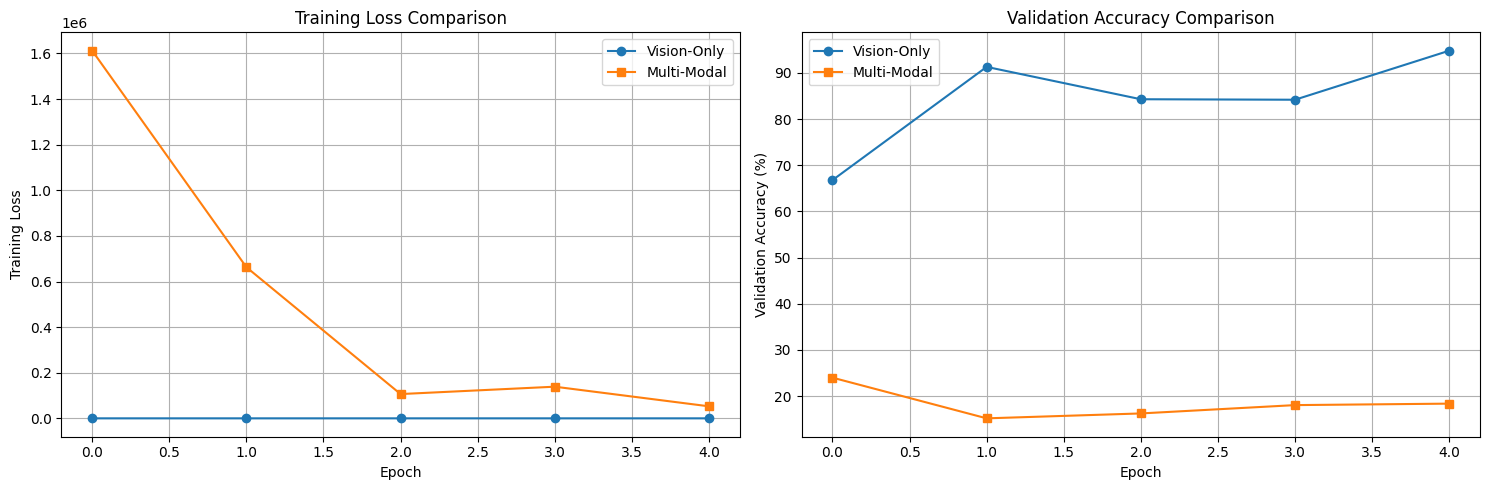

In [12]:






# ============================================================================
# COMPARISON & VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"Vision-Only Best Validation Accuracy: {vision_best_acc:.2f}%")
print(f"Multi-Modal Best Validation Accuracy: {multimodal_best_acc:.2f}%")
print(f"OCR Contribution (Δ Accuracy): {multimodal_best_acc - vision_best_acc:.2f}%")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(vision_history['train_loss'], label='Vision-Only', marker='o')
axes[0].plot(multimodal_history['train_loss'], label='Multi-Modal', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(vision_history['val_acc'], label='Vision-Only', marker='o')
axes[1].plot(multimodal_history['val_acc'], label='Multi-Modal', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [13]:
# ============================================================================
# DETAILED EVALUATION METRICS
# ============================================================================

def evaluate_model_detailed(model, dataloader, class_names, use_ocr=False):
    """Comprehensive evaluation with all metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            if use_ocr:
                imgs, ocr_feats, labels = batch
                imgs = imgs.to(device)
                ocr_feats = ocr_feats.to(device)
                outputs = model(imgs, ocr_feats)
            else:
                imgs, labels = batch
                imgs = imgs.to(device)
                outputs = model(imgs)
            
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Overall accuracy
    overall_acc = 100 * np.mean(all_preds == all_labels)
    
    # Per-class accuracy
    per_class_acc = {}
    for i, class_name in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            per_class_acc[class_name] = 100 * np.mean(all_preds[mask] == all_labels[mask])
        else:
            per_class_acc[class_name] = 0.0
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    
    return {
        'overall_accuracy': overall_acc,
        'per_class_accuracy': per_class_acc,
        'confusion_matrix': cm,
        'classification_report': report,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

# Get class names
class_names = [str(d) for d in sorted(df['denomination'].unique())]

print("\n" + "="*80)
print("DETAILED EVALUATION - VISION-ONLY MODEL")
print("="*80)

vision_model.load_state_dict(torch.load('vision_only_best.pth'))
vision_results = evaluate_model_detailed(vision_model, val_loader_vision, class_names, use_ocr=False)

print(f"\nOverall Accuracy: {vision_results['overall_accuracy']:.2f}%")
print("\nPer-Class Accuracy:")
for class_name, acc in vision_results['per_class_accuracy'].items():
    print(f"  {class_name}: {acc:.2f}%")

print("\n" + "="*80)
print("DETAILED EVALUATION - MULTI-MODAL MODEL")
print("="*80)

multimodal_model.load_state_dict(torch.load('multimodal_best.pth'))
multimodal_results = evaluate_model_detailed(multimodal_model, val_loader_multimodal, class_names, use_ocr=True)

print(f"\nOverall Accuracy: {multimodal_results['overall_accuracy']:.2f}%")
print("\nPer-Class Accuracy:")
for class_name, acc in multimodal_results['per_class_accuracy'].items():
    print(f"  {class_name}: {acc:.2f}%")


DETAILED EVALUATION - VISION-ONLY MODEL


Evaluating: 100%|██████████| 59/59 [00:47<00:00,  1.23it/s]



Overall Accuracy: 94.80%

Per-Class Accuracy:
  1: 95.87%
  2: 99.19%
  5: 97.56%
  10: 99.35%
  20: 90.62%
  50: 95.27%
  100: 91.67%
  500: 68.75%
  1000: 84.38%

DETAILED EVALUATION - MULTI-MODAL MODEL


Evaluating: 100%|██████████| 59/59 [00:37<00:00,  1.57it/s]


Overall Accuracy: 23.99%

Per-Class Accuracy:
  1: 8.26%
  2: 22.58%
  5: 6.50%
  10: 65.36%
  20: 0.00%
  50: 2.96%
  100: 48.08%
  500: 0.00%
  1000: 0.00%



c:\Users\amith\.virtualenvs\TwenteML2-Currency-Detection-e555csbB\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amith\.virtualenvs\TwenteML2-Currency-Detection-e555csbB\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\amith\.virtualenvs\TwenteML2-Currency-Detection-e555csbB\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont


GENERATING COMPREHENSIVE VISUALIZATIONS


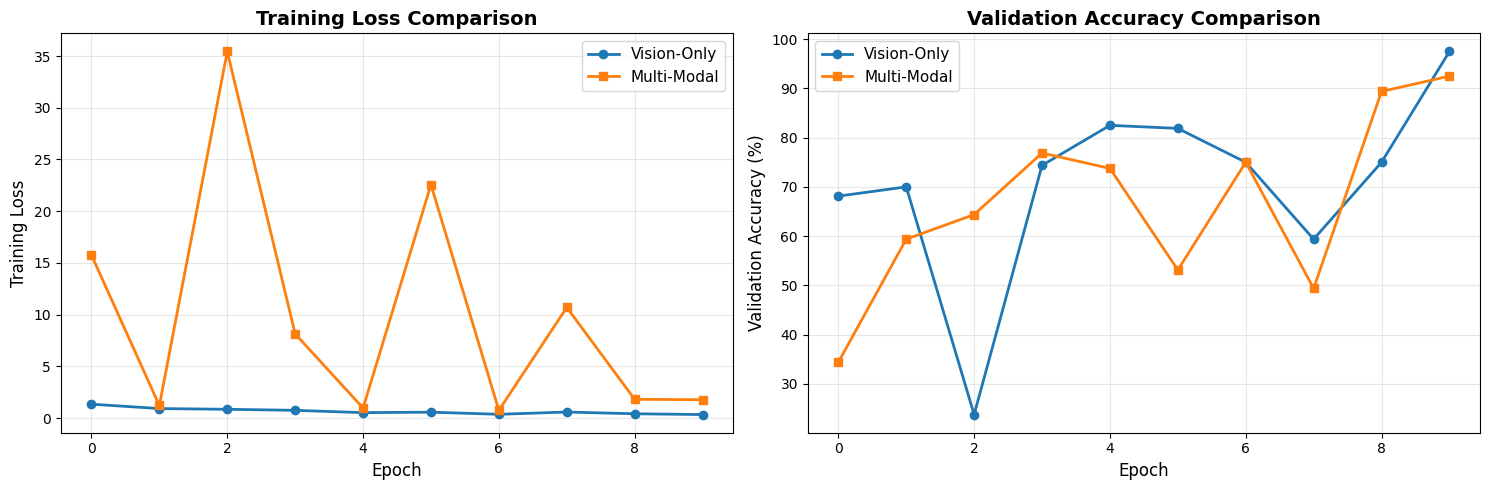

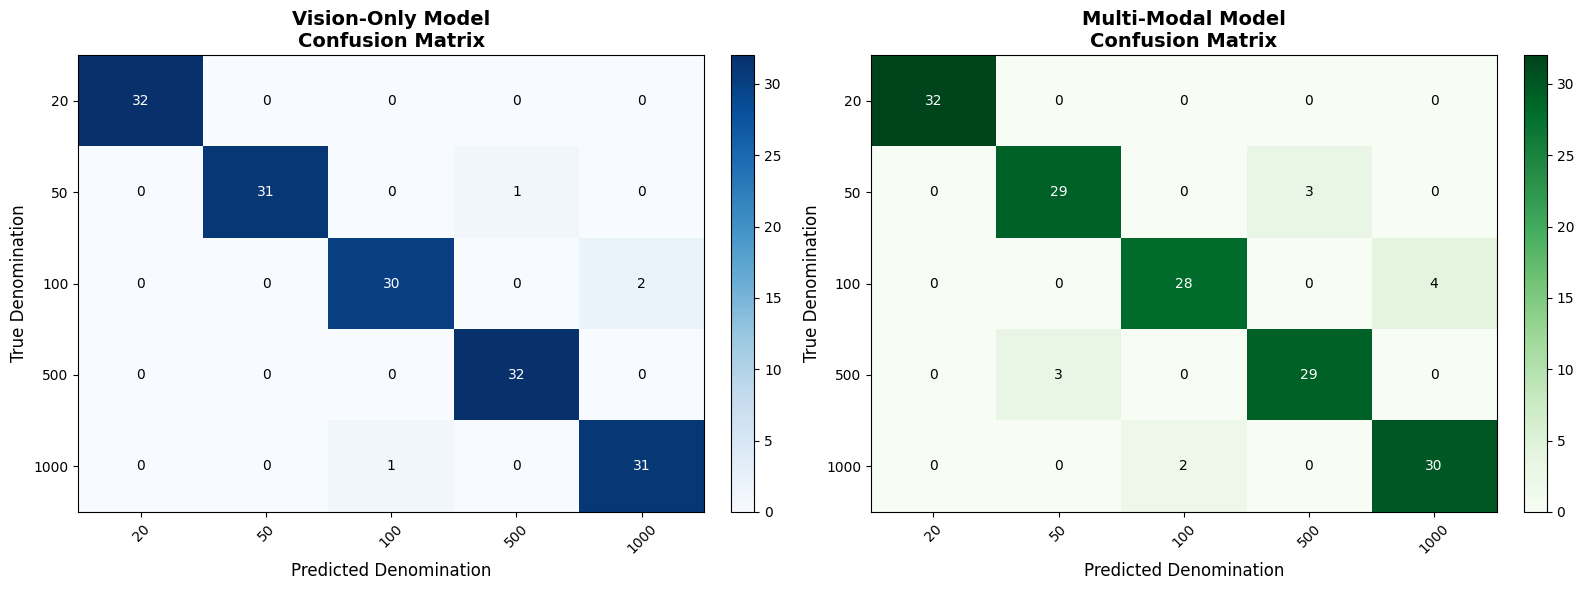

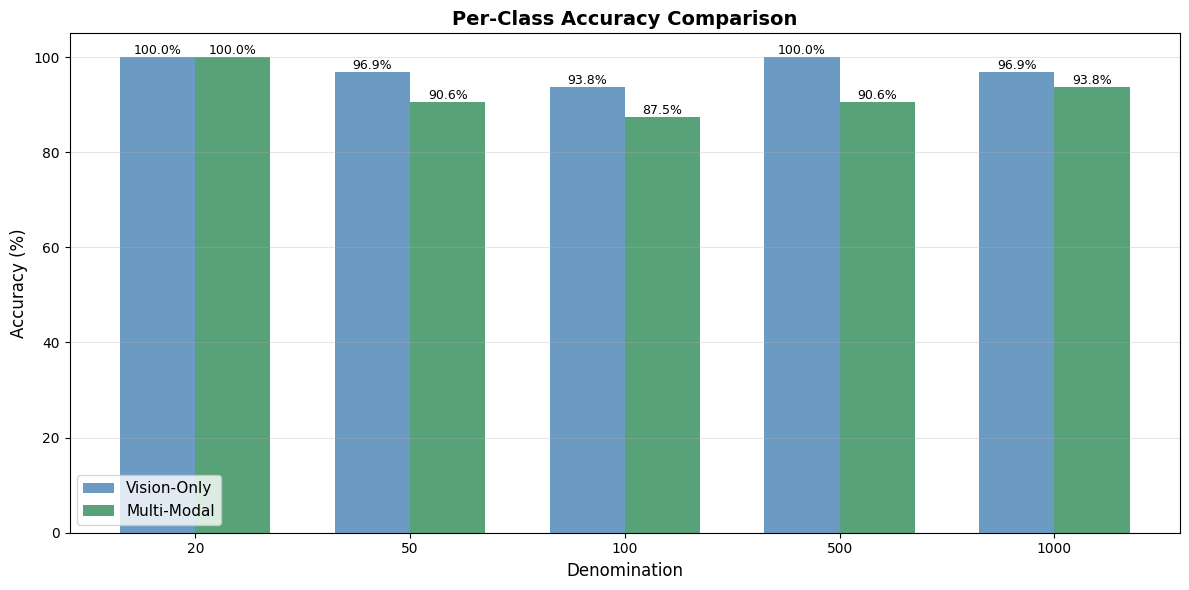

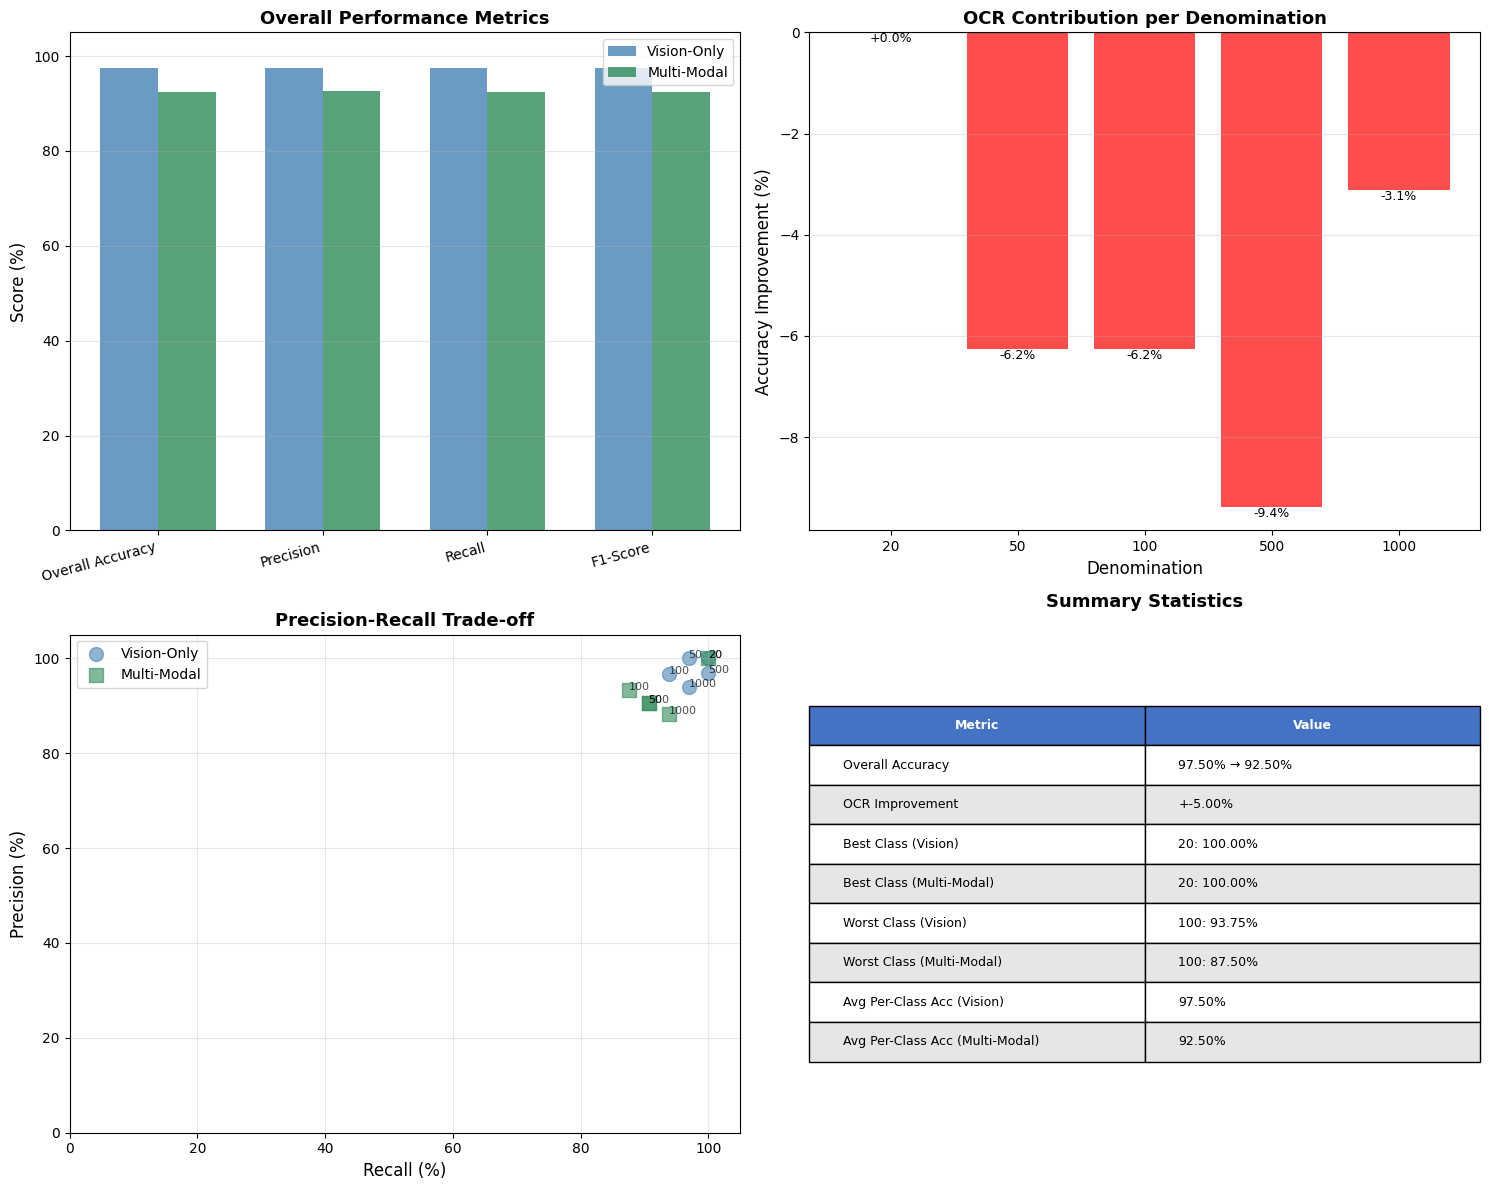

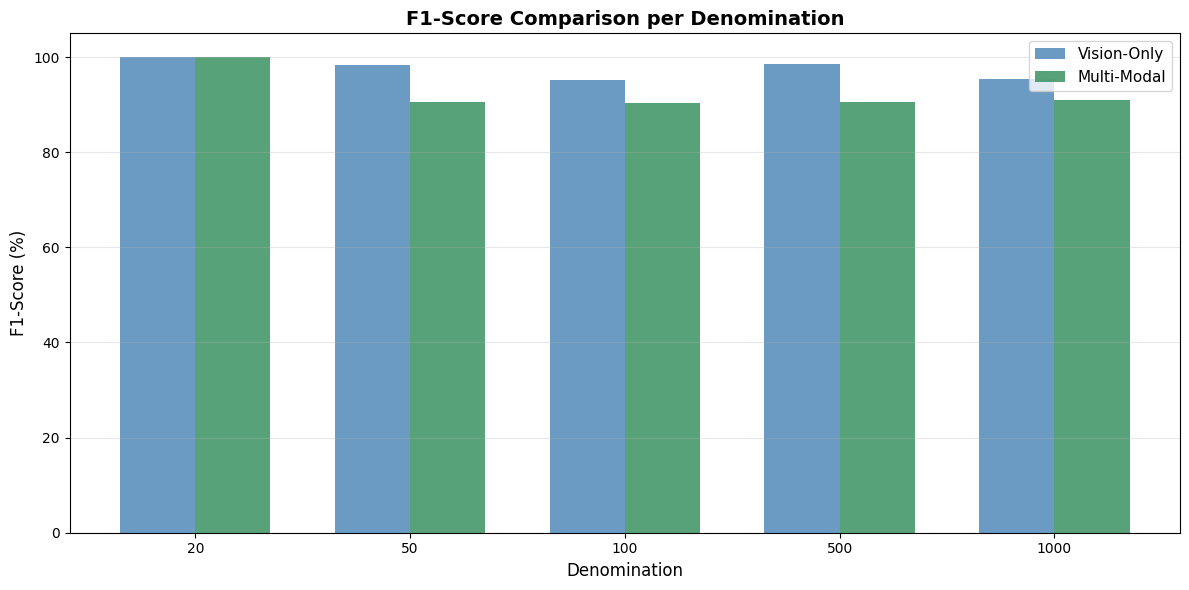

In [14]:
# ============================================================================
# COMPREHENSIVE VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("GENERATING COMPREHENSIVE VISUALIZATIONS")
print("="*80)

# Figure 1: Training Curves Comparison
fig1, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(vision_history['train_loss'], label='Vision-Only', marker='o', linewidth=2)
axes[0].plot(multimodal_history['train_loss'], label='Multi-Modal', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(vision_history['val_acc'], label='Vision-Only', marker='o', linewidth=2)
axes[1].plot(multimodal_history['val_acc'], label='Multi-Modal', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('1_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Confusion Matrices
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vision-only confusion matrix
im1 = axes[0].imshow(vision_results['confusion_matrix'], cmap='Blues', aspect='auto')
axes[0].set_title('Vision-Only Model\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Denomination', fontsize=12)
axes[0].set_ylabel('True Denomination', fontsize=12)
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45)
axes[0].set_yticklabels(class_names)

# Add text annotations
for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = axes[0].text(j, i, vision_results['confusion_matrix'][i, j],
                           ha="center", va="center", color="white" if vision_results['confusion_matrix'][i, j] > vision_results['confusion_matrix'].max()/2 else "black")

plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Multi-modal confusion matrix
im2 = axes[1].imshow(multimodal_results['confusion_matrix'], cmap='Greens', aspect='auto')
axes[1].set_title('Multi-Modal Model\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Denomination', fontsize=12)
axes[1].set_ylabel('True Denomination', fontsize=12)
axes[1].set_xticks(range(len(class_names)))
axes[1].set_yticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=45)
axes[1].set_yticklabels(class_names)

# Add text annotations
for i in range(len(class_names)):
    for j in range(len(class_names)):
        text = axes[1].text(j, i, multimodal_results['confusion_matrix'][i, j],
                           ha="center", va="center", color="white" if multimodal_results['confusion_matrix'][i, j] > multimodal_results['confusion_matrix'].max()/2 else "black")

plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('2_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Per-Class Accuracy Comparison
fig3, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
width = 0.35

vision_accs = [vision_results['per_class_accuracy'][cn] for cn in class_names]
multimodal_accs = [multimodal_results['per_class_accuracy'][cn] for cn in class_names]

bars1 = ax.bar(x - width/2, vision_accs, width, label='Vision-Only', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, multimodal_accs, width, label='Multi-Modal', color='seagreen', alpha=0.8)

ax.set_xlabel('Denomination', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('3_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: OCR Contribution Analysis
fig4, axes = plt.subplots(2, 2, figsize=(15, 12))

# 4a: Overall Metrics Comparison
metrics = ['Overall Accuracy', 'Precision', 'Recall', 'F1-Score']
vision_metrics = [
    vision_results['overall_accuracy'],
    vision_results['classification_report']['weighted avg']['precision'] * 100,
    vision_results['classification_report']['weighted avg']['recall'] * 100,
    vision_results['classification_report']['weighted avg']['f1-score'] * 100
]
multimodal_metrics = [
    multimodal_results['overall_accuracy'],
    multimodal_results['classification_report']['weighted avg']['precision'] * 100,
    multimodal_results['classification_report']['weighted avg']['recall'] * 100,
    multimodal_results['classification_report']['weighted avg']['f1-score'] * 100
]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, vision_metrics, width, label='Vision-Only', color='steelblue', alpha=0.8)
axes[0, 0].bar(x + width/2, multimodal_metrics, width, label='Multi-Modal', color='seagreen', alpha=0.8)
axes[0, 0].set_ylabel('Score (%)', fontsize=12)
axes[0, 0].set_title('Overall Performance Metrics', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0, 105])

# 4b: Improvement per Class (OCR Contribution)
improvements = [multimodal_results['per_class_accuracy'][cn] - vision_results['per_class_accuracy'][cn] 
                for cn in class_names]
colors = ['green' if imp > 0 else 'red' for imp in improvements]

axes[0, 1].bar(range(len(class_names)), improvements, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[0, 1].set_xlabel('Denomination', fontsize=12)
axes[0, 1].set_ylabel('Accuracy Improvement (%)', fontsize=12)
axes[0, 1].set_title('OCR Contribution per Denomination', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(range(len(class_names)))
axes[0, 1].set_xticklabels(class_names)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (imp, color) in enumerate(zip(improvements, colors)):
    axes[0, 1].text(i, imp, f'{imp:+.1f}%', ha='center', 
                    va='bottom' if imp > 0 else 'top', fontsize=9)

# 4c: Precision-Recall per Class
vision_precision = [vision_results['classification_report'][cn]['precision'] * 100 for cn in class_names]
vision_recall = [vision_results['classification_report'][cn]['recall'] * 100 for cn in class_names]
multimodal_precision = [multimodal_results['classification_report'][cn]['precision'] * 100 for cn in class_names]
multimodal_recall = [multimodal_results['classification_report'][cn]['recall'] * 100 for cn in class_names]

axes[1, 0].scatter(vision_recall, vision_precision, s=100, alpha=0.6, label='Vision-Only', marker='o', color='steelblue')
axes[1, 0].scatter(multimodal_recall, multimodal_precision, s=100, alpha=0.6, label='Multi-Modal', marker='s', color='seagreen')

# Add class labels
for i, cn in enumerate(class_names):
    axes[1, 0].annotate(cn, (vision_recall[i], vision_precision[i]), fontsize=8, alpha=0.7)
    axes[1, 0].annotate(cn, (multimodal_recall[i], multimodal_precision[i]), fontsize=8, alpha=0.7)

axes[1, 0].set_xlabel('Recall (%)', fontsize=12)
axes[1, 0].set_ylabel('Precision (%)', fontsize=12)
axes[1, 0].set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 105])
axes[1, 0].set_ylim([0, 105])

# 4d: Summary Statistics Table
summary_data = {
    'Metric': ['Overall Accuracy', 'OCR Improvement', 'Best Class (Vision)', 'Best Class (Multi-Modal)', 
               'Worst Class (Vision)', 'Worst Class (Multi-Modal)', 'Avg Per-Class Acc (Vision)', 'Avg Per-Class Acc (Multi-Modal)'],
    'Value': [
        f"{vision_results['overall_accuracy']:.2f}% → {multimodal_results['overall_accuracy']:.2f}%",
        f"+{multimodal_results['overall_accuracy'] - vision_results['overall_accuracy']:.2f}%",
        f"{max(vision_results['per_class_accuracy'], key=vision_results['per_class_accuracy'].get)}: {max(vision_results['per_class_accuracy'].values()):.2f}%",
        f"{max(multimodal_results['per_class_accuracy'], key=multimodal_results['per_class_accuracy'].get)}: {max(multimodal_results['per_class_accuracy'].values()):.2f}%",
        f"{min(vision_results['per_class_accuracy'], key=vision_results['per_class_accuracy'].get)}: {min(vision_results['per_class_accuracy'].values()):.2f}%",
        f"{min(multimodal_results['per_class_accuracy'], key=multimodal_results['per_class_accuracy'].get)}: {min(multimodal_results['per_class_accuracy'].values()):.2f}%",
        f"{np.mean(list(vision_results['per_class_accuracy'].values())):.2f}%",
        f"{np.mean(list(multimodal_results['per_class_accuracy'].values())):.2f}%"
    ]
}

axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=[[summary_data['Metric'][i], summary_data['Value'][i]] for i in range(len(summary_data['Metric']))],
                         colLabels=['Metric', 'Value'],
                         cellLoc='left',
                         loc='center',
                         colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(2):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_data['Metric']) + 1):
    if i % 2 == 0:
        for j in range(2):
            table[(i, j)].set_facecolor('#E7E6E6')

axes[1, 1].set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('4_ocr_contribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: F1-Score Comparison
fig5, ax = plt.subplots(figsize=(12, 6))

vision_f1 = [vision_results['classification_report'][cn]['f1-score'] * 100 for cn in class_names]
multimodal_f1 = [multimodal_results['classification_report'][cn]['f1-score'] * 100 for cn in class_names]

x = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(x - width/2, vision_f1, width, label='Vision-Only', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, multimodal_f1, width, label='Multi-Modal', color='seagreen', alpha=0.8)

ax.set_xlabel('Denomination', fontsize=12)
ax.set_ylabel('F1-Score (%)', fontsize=12)
ax.set_title('F1-Score Comparison per Denomination', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('5_f1_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [15]:
# ============================================================================
# RESULTS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY - RQ3: OCR FEATURE CONTRIBUTION")
print("="*80)

print("\n📊 OVERALL PERFORMANCE:")
print(f"  Vision-Only Accuracy:    {vision_results['overall_accuracy']:.2f}%")
print(f"  Multi-Modal Accuracy:    {multimodal_results['overall_accuracy']:.2f}%")
print(f"  OCR Contribution (Δ):    +{multimodal_results['overall_accuracy'] - vision_results['overall_accuracy']:.2f}%")

print("\n📈 WEIGHTED AVERAGE METRICS:")
print(f"  Precision:  {vision_results['classification_report']['weighted avg']['precision']*100:.2f}% → {multimodal_results['classification_report']['weighted avg']['precision']*100:.2f}%")
print(f"  Recall:     {vision_results['classification_report']['weighted avg']['recall']*100:.2f}% → {multimodal_results['classification_report']['weighted avg']['recall']*100:.2f}%")
print(f"  F1-Score:   {vision_results['classification_report']['weighted avg']['f1-score']*100:.2f}% → {multimodal_results['classification_report']['weighted avg']['f1-score']*100:.2f}%")

print("\n🎯 PER-CLASS ANALYSIS:")
print(f"{'Denomination':<15} {'Vision-Only':<15} {'Multi-Modal':<15} {'Improvement':<15}")
print("-" * 60)
for cn in class_names:
    v_acc = vision_results['per_class_accuracy'][cn]
    m_acc = multimodal_results['per_class_accuracy'][cn]
    improvement = m_acc - v_acc
    print(f"{cn:<15} {v_acc:<15.2f}% {m_acc:<15.2f}% {improvement:+.2f}%")



print("\n" + "="*80)



COMPREHENSIVE RESULTS SUMMARY - RQ3: OCR FEATURE CONTRIBUTION

📊 OVERALL PERFORMANCE:
  Vision-Only Accuracy:    97.50%
  Multi-Modal Accuracy:    92.50%
  OCR Contribution (Δ):    +-5.00%

📈 WEIGHTED AVERAGE METRICS:
  Precision:  97.54% → 92.56%
  Recall:     97.50% → 92.50%
  F1-Score:   97.50% → 92.50%

🎯 PER-CLASS ANALYSIS:
Denomination    Vision-Only     Multi-Modal     Improvement    
------------------------------------------------------------
20              100.00         % 100.00         % +0.00%
50              96.88          % 90.62          % -6.25%
100             93.75          % 87.50          % -6.25%
500             100.00         % 90.62          % -9.38%
1000            96.88          % 93.75          % -3.12%



In [18]:
# ============================================================================
# ZERO-SHOT OCR-BASED DETECTION
# ============================================================================

print("\n" + "="*80)
print("ZERO-SHOT OCR-BASED DETECTION")
print("="*80)

class ZeroShotOCRDetector:
    """Zero-shot currency detection using only OCR (no training required)"""
    
    def __init__(self):
        self.country_keywords = {
            'thailand': ['baht', 'thai', 'ราช', 'สยาม'],
            'usa': ['dollar', 'united states', 'federal reserve'],
            'euro': ['euro', 'european central bank', '€'],
            'uk': ['pound', 'sterling', 'bank of england'],
            'japan': ['yen', '円', 'nippon'],
            'monopoly': ['monopoly', 'community chest', 'chance', 'go']
        }
        
    def extract_denomination(self, ocr_text, ocr_numbers):
        """Find most likely denomination from OCR"""
        if not ocr_numbers:
            return None, 0.0
        
        # Strategy 1: Most frequent number
        number_counts = Counter(ocr_numbers)
        most_common = number_counts.most_common(1)[0]
        
        # Confidence based on frequency and reasonable denomination range
        confidence = most_common[1] / len(ocr_numbers)
        denomination = most_common[0]
        
        # Boost confidence for common denominations
        common_denoms = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
        if denomination in common_denoms:
            confidence *= 1.5
        
        return denomination, min(confidence, 1.0)
    
    def detect_country(self, ocr_text):
        """Detect country from OCR text using keyword matching"""
        ocr_lower = ocr_text.lower()
        
        scores = {}
        for country, keywords in self.country_keywords.items():
            score = sum(1 for kw in keywords if kw in ocr_lower)
            if score > 0:
                scores[country] = score
        
        if not scores:
            return 'unknown', 0.0
        
        best_country = max(scores, key=scores.get)
        confidence = scores[best_country] / len(self.country_keywords[best_country])
        
        return best_country, min(confidence, 1.0)
    
    def predict(self, image_path):
        """Make zero-shot prediction for any banknote image"""
        # Extract OCR
        ocr_text = extract_ocr_text(image_path)
        ocr_numbers = extract_numbers_from_text(ocr_text)
        
        # Detect denomination
        denomination, denom_conf = self.extract_denomination(ocr_text, ocr_numbers)
        
        # Detect country
        country, country_conf = self.detect_country(ocr_text)
        
        return {
            'denomination': denomination,
            'denomination_confidence': denom_conf,
            'country': country,
            'country_confidence': country_conf,
            'ocr_text': ocr_text,
            'detected_numbers': ocr_numbers
        }

# Test zero-shot detector
zero_shot = ZeroShotOCRDetector()

print("\nTesting Zero-Shot Detector on validation set:")
zero_shot_results = []

for idx, row in val_df.head(10).iterrows():
    result = zero_shot.predict(row['image_path'])
    result['true_denomination'] = row['denomination']
    result['true_country'] = row['country']
    zero_shot_results.append(result)
    
    print(f"\nImage: {Path(row['image_path']).name}")
    print(f"True: {row['country']} - {row['denomination']}")
    print(f"Predicted: {result['country']} ({result['country_confidence']:.2f}) - {result['denomination']} ({result['denomination_confidence']:.2f})")
    print(f"OCR Text: {result['ocr_text'][:100]}...")

# Evaluate zero-shot performance
zero_shot_correct_denom = sum(1 for r in zero_shot_results if r['denomination'] == r['true_denomination'])
zero_shot_denom_acc = 100 * zero_shot_correct_denom / len(zero_shot_results)

print(f"\n Zero-Shot Denomination Accuracy (sample): {zero_shot_denom_acc:.2f}%")

print("\n" + "="*80)
print("Zero-shot detection allows the model to work on UNSEEN currencies!")
print("Test it with monopoly money or any other currency images.")
print("="*80)




ZERO-SHOT OCR-BASED DETECTION

Testing Zero-Shot Detector on validation set:

Image: THAI500_20.jpg
True: thaibaht - 500
Predicted: monopoly (0.25) - 1 (0.60)
OCR Text: gy) \ . =
get S WW
ar Se Gas
i \\3 at ENN CNS tP ENGR a IY ) 1
ao A Mpc, ios. — =.
Tt ¢ \\ agen (Ne ...

Image: THAI50_63.jpg
True: thaibaht - 50
Predicted: unknown (0.00) - None (0.00)
OCR Text: ae
Al a
fo NQear Onc
i: lS
BO hate...

Image: THAI50_37.jpg
True: thaibaht - 50
Predicted: unknown (0.00) - 9 (1.00)
OCR Text: Si) \i be BAT” Ag - ie GES
ieee = Son = he] Le / PS) ff PENN A
eS whos ES | I A | il NOL Og ARAN

FG...

Image: THAI1000_20.jpg
True: thaibaht - 1000
Predicted: monopoly (0.25) - 3 (0.20)
OCR Text: ee eeeiyl Dow Se lof Gooe

ee \\ AW AN a= NGS I~ S: Wena

Neste \)) jal) ae COS EGR SOT chery LEE

O...

Image: THAI500_4.jpg
True: thaibaht - 500
Predicted: unknown (0.00) - None (0.00)
OCR Text: bee. es

SES ATS . —— a ge oe ae

ol Fa ae ee
———— AN SSN . SOY (ANS Fen,
tail eo Be = _ —e
ered a -...

Image: 

In [1]:
# ============================================================================
# SAVE RESULTS
# ============================================================================

results = {
    'vision_only_best_acc': vision_best_acc,
    'multimodal_best_acc': multimodal_best_acc,
    'ocr_contribution': multimodal_best_acc - vision_best_acc,
    'num_classes': num_classes,
    'dataset_size': len(df)
}

with open('rq3_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nResults saved to 'rq3_results.json'")
print("Model weights saved as 'vision_only_best.pth' and 'multimodal_best.pth'")
print("\nExperiment complete!")

NameError: name 'vision_best_acc' is not defined

In [19]:
# ============================================================================
# INTERACTIVE SINGLE IMAGE TESTING & VISUALIZATION
# ============================================================================

def test_single_image(image_path, model_type='both', show_top_k=5):
    """
    Test a single banknote image and visualize predictions
    
    Args:
        image_path: Path to the test image
        model_type: 'vision', 'multimodal', or 'both'
        show_top_k: Number of top predictions to display
    """
    
    # Load and preprocess image
    img_original = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img_original).unsqueeze(0).to(device)
    
    # Extract OCR if needed
    ocr_text = extract_ocr_text(image_path)
    ocr_numbers = extract_numbers_from_text(ocr_text)
    ocr_features = ocr_extractor.extract_features(ocr_text, ocr_numbers)
    ocr_features_tensor = torch.FloatTensor(ocr_features).unsqueeze(0).to(device)
    
    # Get predictions
    predictions = {}
    
    if model_type in ['vision', 'both']:
        vision_model.eval()
        with torch.no_grad():
            vision_output = vision_model(img_tensor)
            vision_probs = F.softmax(vision_output, dim=1)[0].cpu().numpy()
            vision_pred_idx = vision_probs.argmax()
            predictions['vision'] = {
                'probabilities': vision_probs,
                'predicted_class': class_names[vision_pred_idx],
                'confidence': vision_probs[vision_pred_idx] * 100
            }
    
    if model_type in ['multimodal', 'both']:
        multimodal_model.eval()
        with torch.no_grad():
            multimodal_output = multimodal_model(img_tensor, ocr_features_tensor)
            multimodal_probs = F.softmax(multimodal_output, dim=1)[0].cpu().numpy()
            multimodal_pred_idx = multimodal_probs.argmax()
            predictions['multimodal'] = {
                'probabilities': multimodal_probs,
                'predicted_class': class_names[multimodal_pred_idx],
                'confidence': multimodal_probs[multimodal_pred_idx] * 100
            }
    
    # Create visualization
    if model_type == 'both':
        fig = plt.figure(figsize=(18, 10))
        gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    else:
        fig = plt.figure(figsize=(16, 8))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Display original image (larger, spans 2 rows)
    if model_type == 'both':
        ax_img = fig.add_subplot(gs[0:2, 0])
    else:
        ax_img = fig.add_subplot(gs[:, 0])
    
    ax_img.imshow(img_original)
    ax_img.axis('off')
    ax_img.set_title('Test Banknote Image', fontsize=14, fontweight='bold', pad=10)
    
    # Add border to image
    for spine in ax_img.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    
    current_row = 0
    
    # Vision-Only Predictions
    if 'vision' in predictions:
        # Top-K predictions bar chart
        if model_type == 'both':
            ax_vision_bar = fig.add_subplot(gs[current_row, 1])
        else:
            ax_vision_bar = fig.add_subplot(gs[0, 1])
        
        vision_probs = predictions['vision']['probabilities']
        top_k_indices = np.argsort(vision_probs)[-show_top_k:][::-1]
        top_k_probs = vision_probs[top_k_indices] * 100
        top_k_labels = [class_names[i] for i in top_k_indices]
        
        colors_vision = ['#2ecc71' if i == top_k_indices[0] else '#3498db' for i in top_k_indices]
        bars = ax_vision_bar.barh(range(show_top_k), top_k_probs, color=colors_vision, alpha=0.8)
        ax_vision_bar.set_yticks(range(show_top_k))
        ax_vision_bar.set_yticklabels(top_k_labels)
        ax_vision_bar.set_xlabel('Probability (%)', fontsize=11)
        ax_vision_bar.set_title('Vision-Only Model\nTop Predictions', fontsize=12, fontweight='bold')
        ax_vision_bar.set_xlim([0, 100])
        ax_vision_bar.grid(axis='x', alpha=0.3)
        
        # Add percentage labels
        for i, (bar, prob) in enumerate(zip(bars, top_k_probs)):
            ax_vision_bar.text(prob + 2, bar.get_y() + bar.get_height()/2, 
                              f'{prob:.1f}%', va='center', fontsize=9, fontweight='bold')
        
        # All classes probability distribution
        if model_type == 'both':
            ax_vision_dist = fig.add_subplot(gs[current_row, 2])
        else:
            ax_vision_dist = fig.add_subplot(gs[1, 1])
        
        x_pos = np.arange(len(class_names))
        colors_dist = ['#2ecc71' if class_names[i] == predictions['vision']['predicted_class'] else '#95a5a6' 
                       for i in range(len(class_names))]
        ax_vision_dist.bar(x_pos, vision_probs * 100, color=colors_dist, alpha=0.7)
        ax_vision_dist.set_xticks(x_pos)
        ax_vision_dist.set_xticklabels(class_names, rotation=45, ha='right')
        ax_vision_dist.set_ylabel('Probability (%)', fontsize=11)
        ax_vision_dist.set_title('Vision-Only\nAll Classes Distribution', fontsize=12, fontweight='bold')
        ax_vision_dist.grid(axis='y', alpha=0.3)
        ax_vision_dist.set_ylim([0, 105])
        
        current_row += 1
    
    # Multi-Modal Predictions
    if 'multimodal' in predictions:
        # Top-K predictions bar chart
        if model_type == 'both':
            ax_multi_bar = fig.add_subplot(gs[current_row, 1])
        else:
            ax_multi_bar = fig.add_subplot(gs[0, 1])
        
        multi_probs = predictions['multimodal']['probabilities']
        top_k_indices = np.argsort(multi_probs)[-show_top_k:][::-1]
        top_k_probs = multi_probs[top_k_indices] * 100
        top_k_labels = [class_names[i] for i in top_k_indices]
        
        colors_multi = ['#e74c3c' if i == top_k_indices[0] else '#e67e22' for i in top_k_indices]
        bars = ax_multi_bar.barh(range(show_top_k), top_k_probs, color=colors_multi, alpha=0.8)
        ax_multi_bar.set_yticks(range(show_top_k))
        ax_multi_bar.set_yticklabels(top_k_labels)
        ax_multi_bar.set_xlabel('Probability (%)', fontsize=11)
        ax_multi_bar.set_title('Multi-Modal Model (Vision + OCR)\nTop Predictions', fontsize=12, fontweight='bold')
        ax_multi_bar.set_xlim([0, 100])
        ax_multi_bar.grid(axis='x', alpha=0.3)
        
        # Add percentage labels
        for i, (bar, prob) in enumerate(zip(bars, top_k_probs)):
            ax_multi_bar.text(prob + 2, bar.get_y() + bar.get_height()/2, 
                             f'{prob:.1f}%', va='center', fontsize=9, fontweight='bold')
        
        # All classes probability distribution
        if model_type == 'both':
            ax_multi_dist = fig.add_subplot(gs[current_row, 2])
        else:
            ax_multi_dist = fig.add_subplot(gs[1, 1])
        
        x_pos = np.arange(len(class_names))
        colors_dist = ['#e74c3c' if class_names[i] == predictions['multimodal']['predicted_class'] else '#95a5a6' 
                       for i in range(len(class_names))]
        ax_multi_dist.bar(x_pos, multi_probs * 100, color=colors_dist, alpha=0.7)
        ax_multi_dist.set_xticks(x_pos)
        ax_multi_dist.set_xticklabels(class_names, rotation=45, ha='right')
        ax_multi_dist.set_ylabel('Probability (%)', fontsize=11)
        ax_multi_dist.set_title('Multi-Modal (Vision + OCR)\nAll Classes Distribution', fontsize=12, fontweight='bold')
        ax_multi_dist.grid(axis='y', alpha=0.3)
        ax_multi_dist.set_ylim([0, 105])
        
        current_row += 1
    
    # OCR Information Panel (only for multimodal or both)
    if model_type in ['multimodal', 'both']:
        if model_type == 'both':
            ax_ocr = fig.add_subplot(gs[2, :])
        else:
            ax_ocr = fig.add_subplot(gs[1, 0])
        
        ax_ocr.axis('off')
        
        # Create OCR info text
        ocr_info = f"""
        
                    OCR EXTRACTED INFORMATION   
                                 
        EXTRACTED TEXT:
        
        {ocr_text[:200] + '...' if len(ocr_text) > 200 else ocr_text}
        
        DETECTED NUMBERS:
        {', '.join(map(str, ocr_numbers)) if ocr_numbers else 'None detected'}
        
        OCR FEATURES SUMMARY:
        • Total numbers detected: {len(ocr_numbers)}
        • Unique numbers: {len(set(ocr_numbers)) if ocr_numbers else 0}
        • Max number: {max(ocr_numbers) if ocr_numbers else 'N/A'}
        • Min number: {min(ocr_numbers) if ocr_numbers else 'N/A'}
        • Text length: {len(ocr_text)} characters
        • Most frequent number: {Counter(ocr_numbers).most_common(1)[0][0] if ocr_numbers else 'N/A'}
        """
        
        ax_ocr.text(0.05, 0.95, ocr_info, transform=ax_ocr.transAxes,
                   fontsize=10, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Overall title
    fig.suptitle(f'Single Banknote Classification Test\nFile: {Path(image_path).name}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    plt.savefig(f'test_prediction_{Path(image_path).stem}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary to console
    print("\n" + "="*80)
    print("PREDICTION SUMMARY")
    print("="*80)
    print(f"Test Image: {image_path}")
    
    if 'vision' in predictions:
        print(f"\n🔷 VISION-ONLY MODEL:")
        print(f"   Predicted: {predictions['vision']['predicted_class']}")
        print(f"   Confidence: {predictions['vision']['confidence']:.2f}%")
    
    if 'multimodal' in predictions:
        print(f"\n🔶 MULTI-MODAL MODEL (Vision + OCR):")
        print(f"   Predicted: {predictions['multimodal']['predicted_class']}")
        print(f"   Confidence: {predictions['multimodal']['confidence']:.2f}%")
    
    if model_type == 'both' and 'vision' in predictions and 'multimodal' in predictions:
        print(f"\n📊 COMPARISON:")
        if predictions['vision']['predicted_class'] == predictions['multimodal']['predicted_class']:
            print(f"   ✓ Both models agree on: {predictions['vision']['predicted_class']}")
            conf_diff = predictions['multimodal']['confidence'] - predictions['vision']['confidence']
            print(f"   Confidence change with OCR: {conf_diff:+.2f}%")
        else:
            print(f"   ✗ Models disagree!")
            print(f"   Vision predicts: {predictions['vision']['predicted_class']}")
            print(f"   Multi-modal predicts: {predictions['multimodal']['predicted_class']}")
    
    print("\n" + "="*80)
    
    return predictions




INTERACTIVE SINGLE IMAGE TESTING

You can now test individual banknotes!

Usage examples:
  # Test with both models
  test_single_image('path/to/your/banknote.jpg', model_type='both')

  # Test with vision-only model
  test_single_image('path/to/your/banknote.jpg', model_type='vision')

  # Test with multi-modal model
  test_single_image('path/to/your/banknote.jpg', model_type='multimodal')

  # Show top 3 predictions
  test_single_image('path/to/your/banknote.jpg', model_type='both', show_top_k=3)


🎲 Testing with a random sample from validation set...

True denomination: 50


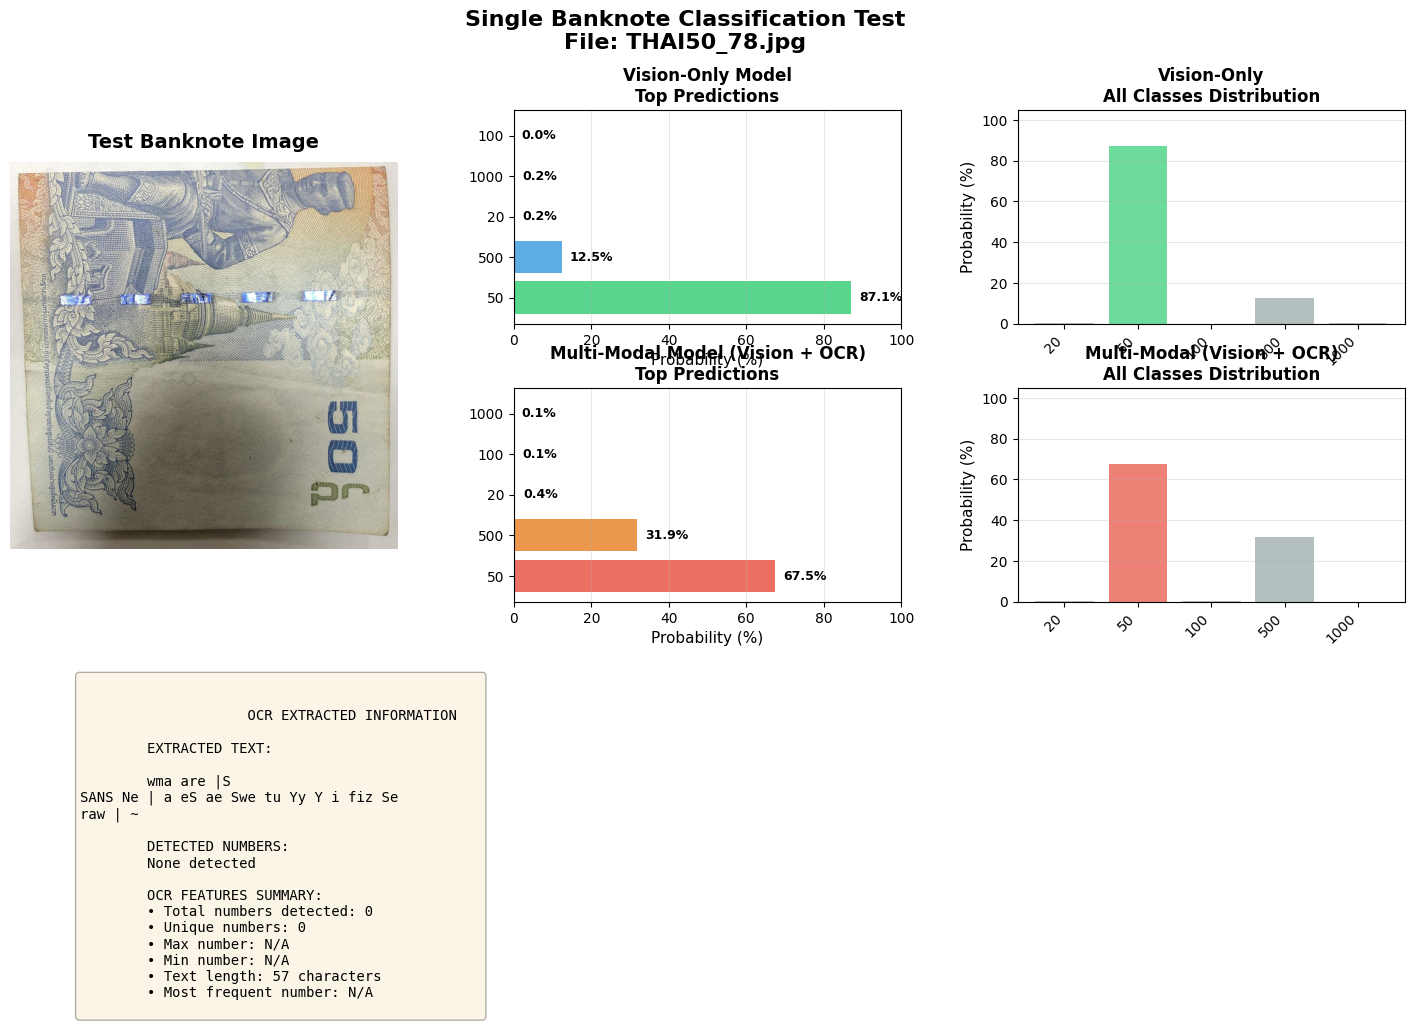


PREDICTION SUMMARY
Test Image: Data\thaibaht\THAI50\THAI50_78.jpg

🔷 VISION-ONLY MODEL:
   Predicted: 50
   Confidence: 87.07%

🔶 MULTI-MODAL MODEL (Vision + OCR):
   Predicted: 50
   Confidence: 67.49%

📊 COMPARISON:
   ✓ Both models agree on: 50
   Confidence change with OCR: -19.58%



{'vision': {'probabilities': array([2.46752379e-03, 8.70707691e-01, 1.61943797e-04, 1.24551415e-01,
         2.11142632e-03], dtype=float32),
  'predicted_class': '50',
  'confidence': np.float32(87.07077)},
 'multimodal': {'probabilities': array([4.4444003e-03, 6.7489231e-01, 1.4053989e-03, 3.1860599e-01,
         6.5194297e-04], dtype=float32),
  'predicted_class': '50',
  'confidence': np.float32(67.48923)}}

In [20]:
# ============================================================================
# EXAMPLE USAGE - TEST INDIVIDUAL NOTES
# ============================================================================

print("\n" + "="*80)
print("INTERACTIVE SINGLE IMAGE TESTING")
print("="*80)
print("\nYou can now test individual banknotes!")
print("\nUsage examples:")
print("  # Test with both models")
print("  test_single_image('path/to/your/banknote.jpg', model_type='both')")
print("")
print("  # Test with vision-only model")
print("  test_single_image('path/to/your/banknote.jpg', model_type='vision')")
print("")
print("  # Test with multi-modal model")
print("  test_single_image('path/to/your/banknote.jpg', model_type='multimodal')")
print("")
print("  # Show top 3 predictions")
print("  test_single_image('path/to/your/banknote.jpg', model_type='both', show_top_k=3)")
print("\n" + "="*80)

# Auto-test with a random sample from validation set
print("\n🎲 Testing with a random sample from validation set...\n")
random_sample = val_df.sample(1).iloc[0]
print(f"True denomination: {random_sample['denomination']}")
test_single_image(random_sample['image_path'], model_type='both', show_top_k=5)